# ==========================================
# 1. CONFIGURACIÓN DE HARDWARE (RTX 2060)
# ==========================================

In [1]:
import tensorflow as tf
from tensorflow.keras import mixed_precision
import os

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU Configurada: {len(gpus)} dispositivo(s)")
    except RuntimeError as e:
        print(e)

mixed_precision.set_global_policy('mixed_float16')
print(f"✅ Política de precisión: {mixed_precision.global_policy().name}")

✅ GPU Configurada: 1 dispositivo(s)
INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 2060, compute capability 7.5
✅ Política de precisión: mixed_float16


# ==========================================
# 2. CARGA DE DATOS (PIPELINE OPTIMIZADO)
# ==========================================

In [2]:
import pathlib
import matplotlib.pyplot as plt
import numpy as np

# Windows
data_dir = pathlib.Path(r'C:\Users\angel\MyCode\ITM-2025-IA\projects\20251015_cnn\data')

batch_size = 64
img_height = 128
img_width = 128
seed = 123

print("\n--- Cargando Dataset de Entrenamiento ---")
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=seed,
  image_size=(img_height, img_width),
  batch_size=batch_size,
  label_mode='categorical'
)

print("\n--- Cargando Dataset de Validación ---")
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=seed,
  image_size=(img_height, img_width),
  batch_size=batch_size,
  label_mode='categorical'
)

class_names = train_ds.class_names
n_classes = len(class_names)
print(f"\nClases encontradas: {class_names}")


--- Cargando Dataset de Entrenamiento ---
Found 48202 files belonging to 5 classes.
Using 38562 files for training.

--- Cargando Dataset de Validación ---
Found 48202 files belonging to 5 classes.
Using 9640 files for validation.

Clases encontradas: ['catarina', 'gato', 'hormiga', 'perro', 'tortuga']


# ==========================================
# 3. OPTIMIZACIÓN DEL FLUJO DE DATOS (CPU -> GPU)
# ==========================================

In [3]:
AUTOTUNE = tf.data.AUTOTUNE

normalization_layer = tf.keras.layers.Rescaling(1./255)

def preprocess(image, label):
    return normalization_layer(image), label

train_ds = train_ds.map(preprocess).cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.map(preprocess).cache().prefetch(buffer_size=AUTOTUNE)

# ==========================================
# 4. DEFINICIÓN DEL MODELO (TU ARQUITECTURA)
# ==========================================

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, LeakyReLU

model = Sequential([
    tf.keras.layers.InputLayer(input_shape=(img_height, img_width, 3)),

    Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu'),
    MaxPooling2D((2, 2), padding='same'),

    Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), padding='same', activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(n_classes, activation='softmax', dtype='float32')
])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 64, 64, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 64, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 32, 32, 64)       0         
 2D)                                                             
                                                                 
 dropout (Dropout)           (None, 32, 32, 64)        0         
                                                                 
 conv2d_2 (Conv2D)           (None, 32, 32, 128)       7

# ==========================================
# 5. COMPILACIÓN Y ENTRENAMIENTO
# ==========================================

In [5]:
INIT_LR = 1e-3
epochs = 40

model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.SGD(learning_rate=INIT_LR),
    metrics=['accuracy'],
)

print(f"\n--- Iniciando Entrenamiento por {epochs} épocas ---")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    verbose=1
)

model.save("gpu_animales_e40_001.h5")
print("Modelo guardado.")


--- Iniciando Entrenamiento por 40 épocas ---
Epoch 1/40
603/603 [==============================] - 49s 38ms/step - loss: 1.5352 - accuracy: 0.3224 - val_loss: 1.4354 - val_accuracy: 0.5538
Epoch 2/40
603/603 [==============================] - 18s 30ms/step - loss: 1.2785 - accuracy: 0.5116 - val_loss: 1.0624 - val_accuracy: 0.6318
Epoch 3/40
603/603 [==============================] - 18s 30ms/step - loss: 0.9695 - accuracy: 0.6382 - val_loss: 0.8384 - val_accuracy: 0.6775
Epoch 4/40
603/603 [==============================] - 18s 30ms/step - loss: 0.7795 - accuracy: 0.7128 - val_loss: 0.6570 - val_accuracy: 0.7655
Epoch 5/40
603/603 [==============================] - 18s 30ms/step - loss: 0.6551 - accuracy: 0.7624 - val_loss: 0.6316 - val_accuracy: 0.7761
Epoch 6/40
603/603 [==============================] - 18s 30ms/step - loss: 0.5668 - accuracy: 0.7986 - val_loss: 0.4887 - val_accuracy: 0.8368
Epoch 7/40
603/603 [==============================] - 18s 30ms/step - loss: 0.5060 - accu

# ==========================================
# 6. VISUALIZACIÓN DE RESULTADOS
# ==========================================

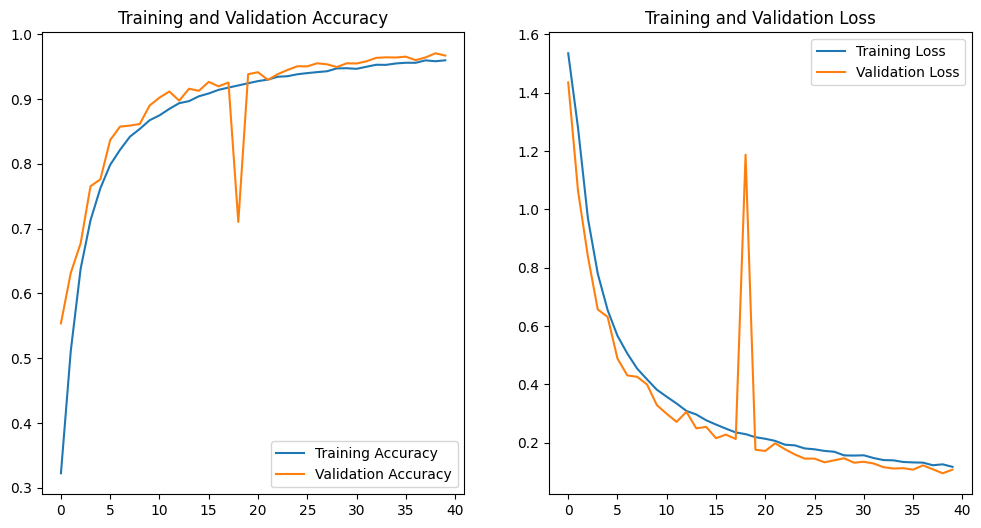

In [6]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

# ==========================================
# 6. TESTING
# ==========================================

Cargando modelo desde C:\Users\angel\MyCode\ITM-2025-IA\projects\20251015_cnn\models\gpu_animales_e40_001.h5...
🌐 Descargando imagen de URL...
1/1 [==============================] - 0s 109ms/step


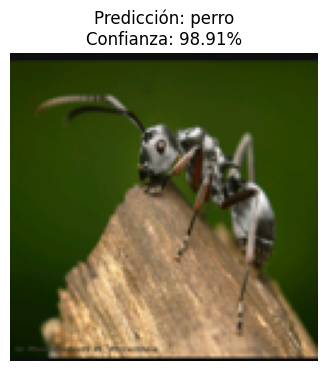

 Resultado: perro (98.91%)
 Probabilidades completas: [6.2862720e-04 6.0548047e-03 3.3024160e-04 9.8906994e-01 3.9163246e-03]


In [24]:
from tensorflow.keras.preprocessing import image
import requests
from io import BytesIO
from PIL import Image

MODEL_PATH = pathlib.Path(r'C:\Users\angel\MyCode\ITM-2025-IA\projects\20251015_cnn\models\gpu_animales_e40_001.h5')
IMG_SIZE = (128, 128)
class_names = ['catarina', 'gato', 'hormiga', 'perro', 'tortuga']

print(f"Cargando modelo desde {MODEL_PATH}...")
model = tf.keras.models.load_model(MODEL_PATH)

def cargar_imagen(path_or_url):
    """
    Carga una imagen desde una ruta local o una URL, 
    la redimensiona y asegura que esté en formato RGB.
    """
    path_str = str(path_or_url)

    if path_str.startswith(('http://', 'https://')):
        print(f"🌐 Descargando imagen de URL...")
        response = requests.get(path_str)
        response.raise_for_status()
        img = Image.open(BytesIO(response.content))
        img = img.resize(IMG_SIZE)
    else:
        print(f"📂 Cargando imagen local...")
        img = image.load_img(path_or_url, target_size=IMG_SIZE)
    if img.mode != 'RGB':
        img = img.convert('RGB')
    return img

def predecir_imagen(img_path):
    try:
        img = cargar_imagen(img_path)

        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = img_array / 255.0

        predictions = model.predict(img_array)
        score = predictions[0]

        predicted_class = class_names[np.argmax(score)]
        confidence = 100 * np.max(score)

        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Predicción: {predicted_class}\nConfianza: {confidence:.2f}%")
        plt.show()

        print(f" Resultado: {predicted_class} ({confidence:.2f}%)")
        print(f" Probabilidades completas: {score}")

    except Exception as e:
        print(f"❌ Error al procesar la imagen: {e}")


ruta_local = pathlib.Path(r'C:\Users\angel\MyCode\ITM-2025-IA\projects\20251015_cnn\image.png')

url_internet = "https://pm1.aminoapps.com/7101/8b533fc30836d89d856e5e9f631e483e1f47f6adr1-720-560v2_hq.jpg"
predecir_imagen(url_internet)